# Continuous IQN Dead-End Detection — Comparison with Paper Baselines

Evaluates our **Continuous IQN** D- and R-networks on the MIMIC-IV sepsis cohort and
produces the same figures as the DistDeD paper (Killian et al., 2023), overlaying our
continuous-action results against the **hard-coded discrete-action paper baselines**.

**Run this notebook in Google Colab.**  Add a secret named `GITHUB_TOKEN` with a personal
access token that has read access to the repo.

| Paper Figure | This notebook |
|---|---|
| Fig 7 — ROC curves | Cell 13 |
| Fig 8 — AUC vs VaR threshold | Cell 14 |
| Table 7 — % trajectories missed | Cell 15 |
| Fig 5 — Hours ahead of death | Cell 16 |
| Fig 4 — Value traces around flag | Cell 17 |
| Table 1 — AUC comparison | Cell 18 |

### Hard-coded paper baselines (discrete 25-action IQN on 55-dim NCDE states)
| Method | AUC |
|---|---|
| DeD — DDQN, no CQL | 0.6629 |
| DeD+CQL — DDQN, CQL | 0.7687 |
| DistDeD−CQL — IQN, no CQL | 0.7744 |
| DistDeD — IQN, CQL | **0.7912** |

## Step 1: Clone repository and install dependencies

In [1]:
import os
from google.colab import userdata

# Clone only if the repo isn't already there (safe to re-run after restart)
if not os.path.exists('/content/tmp'):
    token = userdata.get('GITHUB_TOKEN')
    os.system(f'git clone -b mimic https://{token}@github.com/jaym-01/ContinuousDeD.git /content/tmp')

%pip install -r /content/tmp/requirements.txt -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8

In [ ]:
import numpy as np
if np.__version__ != '2.4.2':
    print(f'numpy {np.__version__} detected — restarting to load 2.4.2 ...')
    import os; os.kill(os.getpid(), 9)
else:
    print(f'numpy {np.__version__} ✓ — no restart needed, continue to next cell')

In [20]:
%cd /content/tmp
import os, sys
sys.path.insert(0, '/content/tmp')
print('Working directory:', os.getcwd())

/content/tmp
Working directory: /content/tmp


## Step 2: Preprocess and encode patient trajectories (skip if already done)

In [3]:
TEST_NPZ = 'data/continuous_mimic/rectilinear_processed/encoded_test.npz'

if os.path.exists(TEST_NPZ):
    print('Encoded data already present — skipping preprocessing.')
else:
    print('Running preprocessing pipeline...')
    !python preprocess_ncde_data.py
    print('Preprocessing done.')

Encoded data already present — skipping preprocessing.


In [4]:
if os.path.exists(TEST_NPZ):
    print('Encoded data already present — skipping encoding.')
else:
    print('Encoding trajectories with NCDE (this may take several minutes)...')
    !python encode_data.py
    print('Encoding done.')

import numpy as np
npz = np.load(TEST_NPZ, allow_pickle=True)
print(f"encoded_test.npz: states {npz['states'].shape}, "
      f"actions {npz['actions'].shape}, rewards {npz['rewards'].shape}")

Encoded data already present — skipping encoding.
encoded_test.npz: states (1377, 73, 64), actions (1377, 73, 2), rewards (1377, 73, 1)


## Step 3: Imports, config, and model loading

In [5]:
import pickle, yaml, types
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.lines import Line2D

from rl_utils import ContinuousIQN_OfflineAgent
from analysis_utils import pre_flag_splitting, create_analysis_df, compute_auc, compare_flag_range
from plot_utils import plot_value_hists
from analysis_utils import th as _th
_thresholds_mod = types.ModuleType('thresholds')
_thresholds_mod.th = _th
sys.modules['thresholds'] = _thresholds_mod
from base_analysis import comp_flag_agg_values

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [ ]:
REPO_ROOT   = os.getcwd()
CONFIG_PATH = os.path.join(REPO_ROOT, 'configs', 'iqn_continuous_mimic.yaml')
params = yaml.safe_load(open(CONFIG_PATH))

DATA_DIR = os.path.join(REPO_ROOT, params['data_dir'])
CKPT_DIR = os.path.join(REPO_ROOT, params['checkpoint_fname'])

# Load encoded test data
enc_test = np.load(os.path.join(DATA_DIR, 'encoded_test.npz'), allow_pickle=True)
print(f'Test set : {len(enc_test["states"])} patients')

# ── State normalisation stats ─────────────────────────────────────────────────
# NOTE: state_norm_stats.npz holds mean/std of the 64-dim NCDE-encoded states,
# used to normalise inputs to the D/R IQN networks.
# It is NOT the same as norm_stats.npz, which normalises raw patient features
# (temporal_mean/std for 37 temporal features + static_mean/std for 4 static).
#
# train_rl.py computes these stats but does NOT save them to disk.
# The file exists because it was committed alongside the model checkpoints.
# If it is missing (e.g. after a fresh training run), we recompute it here
# from encoded_train.npz.
NORM_STATS_PATH = os.path.join(CKPT_DIR, 'state_norm_stats.npz')

if os.path.exists(NORM_STATS_PATH):
    nc = np.load(NORM_STATS_PATH)
    state_mean = nc['state_mean']
    state_std  = nc['state_std']
    print(f'Loaded state_norm_stats.npz  (committed artifact)')
else:
    print('state_norm_stats.npz not found — computing from encoded_train.npz ...')
    enc_train  = np.load(os.path.join(DATA_DIR, 'encoded_train.npz'), allow_pickle=True)
    states = enc_train['states']
    lengths = enc_train['lengths']

    # 1. Figure out the feature dimension from the first patient
    feature_dim = states[0].shape[1]

    # 2. Initialize our accumulators with float64 to prevent overflow
    total_count = 0
    sum_states = np.zeros(feature_dim, dtype=np.float64)
    sum_sq_states = np.zeros(feature_dim, dtype=np.float64)

    # 3. Iterate through each patient one by one
    for i in range(len(states)):
        valid_len = int(lengths[i][0])
        patient_states = states[i][:valid_len]

        # Accumulate the counts, sums, and sum of squares
        total_count += valid_len
        sum_states += np.sum(patient_states, axis=0)
        sum_sq_states += np.sum(patient_states ** 2, axis=0)

    # 4. Compute the final mean and standard deviation
    state_mean = sum_states / total_count

    # Calculate variance: (E[X^2] - (E[X])^2)
    state_var = (sum_sq_states / total_count) - (state_mean ** 2)

    # np.maximum ensures no negative variances due to minor floating-point errors
    state_std = np.sqrt(np.maximum(state_var, 0)).clip(min=1e-8)

    os.makedirs(CKPT_DIR, exist_ok=True)
    np.savez(NORM_STATS_PATH, state_mean=state_mean, state_std=state_std)
    print(f'Computed and saved to {NORM_STATS_PATH}')

params['state_mean'] = state_mean
params['state_std']  = state_std
params['input_dim']  = state_mean.shape[0]
print(f'State dim : {params["input_dim"]}')
print(f'state_mean: min={state_mean.min():.4f}  max={state_mean.max():.4f}')
print(f'state_std : min={state_std.min():.4f}   max={state_std.max():.4f}')

Test set : 1377 patients
state_norm_stats.npz not found — computing from encoded_train.npz ...


For some reason, the R network has the configuration of the yaml file (num_q_hidden_units=128, num_q_layers=2, K_actions=64) but not the D network (num_q_hidden_units=256, num_q_layers=3, K_actions=128). Also, in figure 1 at the bottom of this notebook, we can see that the R network has only 2 epochs, while the D network has 15 epochs.

My guess as to what happened: in the train_mimic_continuous.ipynb notebook, I ran the cell with the smoke test which created the 2-epoch version of the model (num_q_hidden_units=128, num_q_layers=2, K_actions=64). Then I ran the full training (num_q_hidden_units=256, num_q_layers=3, K_actions=128) for 75 epochs but I ran out of GPU allowance so it stopped at 15 epochs. Since the train_rl.py file trains the negative network D first, and then the positive network R,
only the R network's weight have been updated after 15 epochs, and not the D network's weights.

If you retrain the continuous agent correctly, you can comment out the next cell and change params2 to params in the cell after.

In [11]:
#READ THE MARKDOWN EXPLANATION ABOVE
#For some reason, the R network has the config of the yaml file but not the D network
params['num_q_hidden_units'] = 256
params['num_q_layers']  = 3
params['K_actions']  = 128

params2 = yaml.safe_load(open(CONFIG_PATH))
params2['state_mean'] = state_mean
params2['state_std']  = state_std
params2['input_dim']  = state_mean.shape[0]

In [12]:
def load_continuous_rl(params, sided_Q, device):
    ckpt_path = os.path.join(CKPT_DIR, f'best_q_parameters{sided_Q}.pt')
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    agent = ContinuousIQN_OfflineAgent(
        state_size=params['input_dim'],
        params=params,
        sided_Q=sided_Q,
        device=device,
    )
    agent.network.load_state_dict(ckpt['rl_network_state_dict'])
    agent.eval()
    print(f"Loaded {sided_Q} network — epoch {ckpt['epoch'] + 1}, "
          f"best val loss = {ckpt['validation_loss'][-1]:.6f}")
    return agent, ckpt

agent_dn, ckpt_dn = load_continuous_rl(params, 'negative', device)
agent_rn, ckpt_rn = load_continuous_rl(params2, 'positive', device) #READ THE MARKDOWN EXPLANATION ABOVE

ContinuousIQN(
  (head): Linear(in_features=66, out_features=256, bias=True)
  (cos_embedding): Linear(in_features=64, out_features=256, bias=True)
  (ff_1): Linear(in_features=256, out_features=256, bias=True)
  (ff_2): Linear(in_features=256, out_features=1, bias=True)
)
Loaded negative network — epoch 1, best val loss = 0.000477
ContinuousIQN(
  (head): Linear(in_features=66, out_features=128, bias=True)
  (cos_embedding): Linear(in_features=64, out_features=128, bias=True)
  (ff_1): Linear(in_features=128, out_features=128, bias=True)
  (ff_2): Linear(in_features=128, out_features=1, bias=True)
)
Loaded positive network — epoch 2, best val loss = 0.002470


## Step 4: Evaluate networks on test set (cached)

In [22]:
#Fixes out-of-memory error
def get_continuous_dn_rn_info(agent_dn, agent_rn, encoded_data, device, num_q_samples=64):
    agent_dn.eval()
    agent_rn.eval()

    n_total = len(encoded_data['states'])

    # ==========================================
    # PASS 1: Count total valid steps to pre-allocate memory
    # ==========================================
    total_steps = 0
    valid_trajectories = [] # Store metadata so we don't recalculate it

    for traj in range(n_total):
        traj_len = int(encoded_data['lengths'][traj][0])
        traj_r   = encoded_data['rewards'][traj][:traj_len]
        terminal_r = float(traj_r[-1].flatten()[0])

        if terminal_r in (-1.0, 1.0):
            category = -1 if terminal_r < 0 else 1
            total_steps += traj_len
            valid_trajectories.append((traj, traj_len, category))

    n_kept = len(valid_trajectories)
    print(f'Pass 1 complete: Found {n_kept}/{n_total} valid patients, total {total_steps} steps.')

    if total_steps == 0:
        return {} # Failsafe

    # ==========================================
    # PRE-ALLOCATE MEMORY (Zero concatenation later)
    # ==========================================
    # Peek at the first valid trajectory to dynamically get state and action dimensions
    first_valid_traj = valid_trajectories[0][0]
    s_dim = encoded_data['states'][first_valid_traj].shape[1]

    # Handle action dimensions dynamically (whether 1D or 2D)
    sample_action = encoded_data['actions'][first_valid_traj]
    a_shape = (total_steps,) if sample_action.ndim == 1 else (total_steps, sample_action.shape[1])

    data = {
        'traj': np.empty(total_steps, dtype=np.int32),
        'step': np.empty(total_steps, dtype=np.int32),
        's': np.empty((total_steps, s_dim), dtype=np.float32),      # Force float32
        'a': np.empty(a_shape, dtype=np.float32),                   # Force float32
        'q_dn': np.empty((total_steps, num_q_samples, 1), dtype=np.float32), #Having to add an extra dimension for step 5
        'q_rn': np.empty((total_steps, num_q_samples, 1), dtype=np.float32), #Having to add an extra dimension for step 5
        'category': np.empty(total_steps, dtype=np.int8),
        'stay_id': np.empty(total_steps, dtype=np.int64),           # IDs can be large ints
    }

    # ==========================================
    # PASS 2: Process models and fill arrays in-place
    # ==========================================
    current_idx = 0

    with torch.no_grad():
        for traj, traj_len, category in valid_trajectories:
            traj_sid = encoded_data['stay_ids'][traj]

            traj_states = torch.from_numpy(
                encoded_data['states'][traj][:traj_len]
            ).float().to(device)

            traj_actions = torch.from_numpy(
                encoded_data['actions'][traj][:traj_len]
            ).float().to(device)

            q_dn_dist, _ = agent_dn.network(traj_states, traj_actions, num_q_samples)
            q_rn_dist, _ = agent_rn.network(traj_states, traj_actions, num_q_samples)

            q_dn_np = np.sort(np.clip(q_dn_dist.cpu().numpy(), -1.0, 0.0), axis=1).astype(np.float32)
            q_rn_np = np.sort(np.clip(q_rn_dist.cpu().numpy(),  0.0, 1.0), axis=1).astype(np.float32)

            # Define the slice where this patient's data goes
            end_idx = current_idx + traj_len

            # Fill the pre-allocated arrays
            data['traj'][current_idx:end_idx] = traj
            data['step'][current_idx:end_idx] = np.arange(traj_len)
            data['s'][current_idx:end_idx] = traj_states.cpu().numpy().astype(np.float32)
            data['a'][current_idx:end_idx] = traj_actions.cpu().numpy().astype(np.float32)
            data['stay_id'][current_idx:end_idx] = traj_sid
            data['q_dn'][current_idx:end_idx] = q_dn_np
            data['q_rn'][current_idx:end_idx] = q_rn_np
            data['category'][current_idx:end_idx] = category

            # Move the pointer forward
            current_idx = end_idx

    print(f'Pass 2 complete. {n_kept} trajectories processed '
          f'({n_total - n_kept} censored patients skipped)')

    # === PANDAS COMPATIBILITY FIX FOR STEP 5===
    # Pandas refuses to put 2D NumPy arrays into a single DataFrame column.
    # We convert our 2D arrays into lists of 1D array views.
    # This gives Pandas the 1D structure it requires without duplicating memory.
    data['s'] = list(data['s'])
    data['q_dn'] = list(data['q_dn'])
    data['q_rn'] = list(data['q_rn'])

    # If actions are also multi-dimensional, list-ify them too
    if data['a'].ndim > 1:
        data['a'] = list(data['a'])

    return data

CACHE_PATH = os.path.join(CKPT_DIR, 'value_data.pkl')

if os.path.exists(CACHE_PATH):
    print(f'Loading cached value data from {CACHE_PATH}')
    with open(CACHE_PATH, 'rb') as f:
        value_data = pickle.load(f)
else:
    print('Evaluating networks on test set...')
    value_data = get_continuous_dn_rn_info(
        agent_dn, agent_rn, enc_test, device, num_q_samples=64
    )
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(value_data, f)
    print(f'Cached to {CACHE_PATH}')

_cats = pd.DataFrame({'traj': value_data['traj'], 'cat': value_data['category']})\
         .drop_duplicates('traj')['cat']
print(f'Survivors     (cat= 1): {(_cats == 1).sum()}')
print(f'Non-survivors (cat=-1): {(_cats ==-1).sum()}')

Evaluating networks on test set...
Pass 1 complete: Found 1377/1377 valid patients, total 58784 steps.
Pass 2 complete. 1377 trajectories processed (0 censored patients skipped)
Cached to /content/drive/MyDrive/ContinuousDeD-mimic/runs/iqn_continuous_mimic/value_data.pkl
Survivors     (cat= 1): 1197
Non-survivors (cat=-1): 180


## Step 5: Pre-flag splitting and analysis DataFrames

In [31]:
VaR_thresholds = np.round(np.linspace(0.05, 1.0, num=20), decimals=2)
print(f'VaR thresholds (alpha): {VaR_thresholds}')

results = pre_flag_splitting(value_data, VaR_thresholds, distributional=True)

n_survivors    = len(results['survivors']['dn_q_selected_action_traj'])
n_nonsurvivors = len(results['nonsurvivors']['dn_q_selected_action_traj'])
print(f'\nSurvivors: {n_survivors}, Non-survivors: {n_nonsurvivors}')

surv_df, nonsurv_df = create_analysis_df(results, n_survivors, n_nonsurvivors)
print(f'surv_df shape: {surv_df.shape},  nonsurv_df shape: {nonsurv_df.shape}')

VaR thresholds (alpha): [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
----------- Non-survivors
+++++++++++ Survivors

Survivors: 1197, Non-survivors: 180
surv_df shape: (50276, 6),  nonsurv_df shape: (8508, 6)


## Hard-coded paper baselines

Numbers from Killian et al. (2023), discrete-action DistDeD on MIMIC-IV sepsis cohort
(42 features → 55-dim NCDE states, 25 discrete actions, test set = 1,070 survivors / 167 non-survivors).

**Table 1**: AUC comparison  
**Table 7**: % trajectories missed at δD = −0.5, δR = 0.5

In [33]:
# ── Table 1 ──────────────────────────────────────────────────────────────────
# Mean AUC (averaged over all VaR alpha settings where applicable)
PAPER_AUC = {
    'DeD\n(DDQN, No CQL)':       0.6629,
    'DeD+CQL\n(DDQN, CQL)':      0.7687,
    'DistDeD−CQL\n(IQN, No CQL)': 0.7744,
    'DistDeD\n(IQN, CQL)':        0.7912,
}

# ── Table 7 ──────────────────────────────────────────────────────────────────
# % of trajectories MISSED (no flag raised) at δD=−0.5, δR=0.5
# Paper test set: 167 non-survivors, 1070 survivors
PAPER_VAR_ALPHAS = np.array([
    0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
    0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00,
])

# DistDeD % missed (non-survivors and survivors)
PAPER_DISTDED_MISSED_NS = np.array([
     4.790,  8.982, 10.180, 12.574, 13.772, 15.569, 17.964, 19.760, 21.557, 22.754,
    23.952, 26.347, 28.144, 30.539, 31.737, 34.131, 35.329, 36.527, 38.323, 41.916,
])
PAPER_DISTDED_MISSED_S = np.array([
    20.074, 30.439, 37.721, 44.071, 49.393, 54.435, 57.330, 60.598, 63.772, 66.013,
    68.627, 70.588, 72.549, 74.510, 76.657, 78.711, 79.925, 80.486, 81.979, 83.660,
])
# DeD % missed (constant across alpha — no distributional risk tuning)
PAPER_DED_MISSED_NS = 59.281
PAPER_DED_MISSED_S  = 88.982

print('Paper baselines loaded.')
print(f'  DeD AUC            : {PAPER_AUC["DeD\n(DDQN, No CQL)"]:.4f}')
print(f'  DistDeD AUC        : {PAPER_AUC["DistDeD\n(IQN, CQL)"]:.4f}')
print(f'  DeD missed NS      : {PAPER_DED_MISSED_NS:.1f}%')
print(f'  DistDeD missed NS  : {PAPER_DISTDED_MISSED_NS.min():.1f}% – {PAPER_DISTDED_MISSED_NS.max():.1f}% (over alpha)')

Paper baselines loaded.
  DeD AUC            : 0.6629
  DistDeD AUC        : 0.7912
  DeD missed NS      : 59.3%
  DistDeD missed NS  : 4.8% – 41.9% (over alpha)


## Figure 1 — Training loss curves

Uses the saved `q_losses_*.npy` epoch-loss arrays from the checkpoint directory.

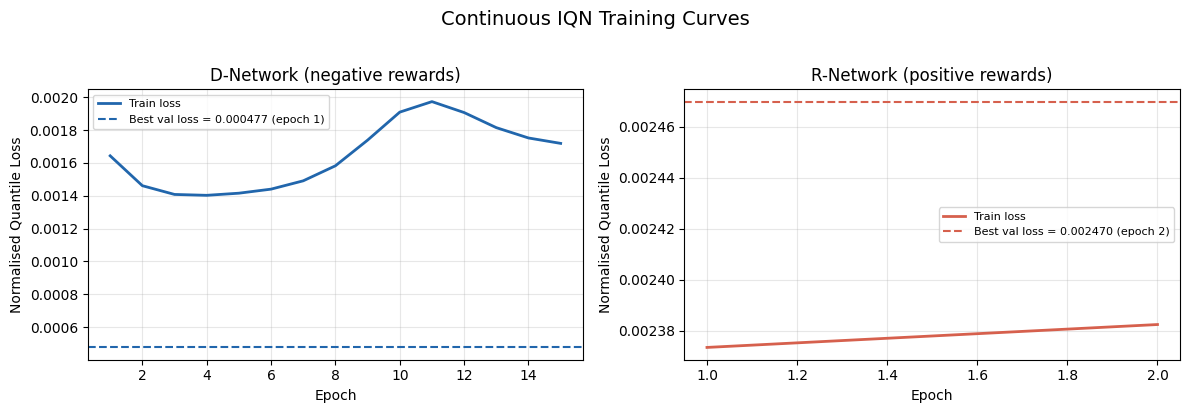

In [34]:
losses_dn_path = os.path.join(CKPT_DIR, 'q_losses_negative.npy')
losses_rn_path = os.path.join(CKPT_DIR, 'q_losses_positive.npy')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, loss_path, ckpt, title, col in zip(
    axes,
    [losses_dn_path, losses_rn_path],
    [ckpt_dn, ckpt_rn],
    ['D-Network (negative rewards)', 'R-Network (positive rewards)'],
    ['#2166ac', '#d6604d'],
):
    if os.path.exists(loss_path):
        train_losses = np.load(loss_path)
        epochs = np.arange(1, len(train_losses) + 1)
        ax.plot(epochs, train_losses, label='Train loss', color=col, linewidth=2)
    # Best-epoch validation loss from checkpoint
    best_epoch = ckpt['epoch'] + 1
    best_val   = ckpt['validation_loss'][-1]
    ax.axhline(best_val, color=col, linestyle='--', linewidth=1.5,
               label=f'Best val loss = {best_val:.6f} (epoch {best_epoch})')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Normalised Quantile Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Continuous IQN Training Curves', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()
fig_training = fig

## Figure 2 — ROC curves  *(paper Figure 7 equivalent)*

Each green curve = one CVaR α setting of our continuous IQN.  
Dashed vertical reference lines show the paper's AUC values for DeD and DistDeD baselines.

In [36]:
import os, sys, time
import random
import pickle
import click
import yaml

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import auc

import torch

In [37]:
print('Computing AUC (this may take a few minutes)...')
fpr, tpr, auc_out = compute_auc(
    surv_df, nonsurv_df, n_survivors, n_nonsurvivors, iqn_size=20
)
auc_vals = auc_out[0]   # shape (20,)

print(f'\nAUC per CVaR alpha:')
print(f'{"Alpha":>8}  {"AUC":>8}')
print('-' * 20)
for alpha, auc_v in zip(VaR_thresholds, auc_vals):
    print(f'{alpha:>8.2f}  {auc_v:>8.4f}')
print(f'\nBest AUC : {auc_vals.max():.4f}  (alpha = {VaR_thresholds[auc_vals.argmax()]:.2f})')
print(f'Mean AUC : {auc_vals.mean():.4f}')

Computing AUC (this may take a few minutes)...

AUC per CVaR alpha:
   Alpha       AUC
--------------------
    0.05    0.6637
    0.10    0.6620
    0.15    0.6634
    0.20    0.6658
    0.25    0.6679
    0.30    0.6696
    0.35    0.6711
    0.40    0.6736
    0.45    0.6754
    0.50    0.6769
    0.55    0.6784
    0.60    0.6801
    0.65    0.6819
    0.70    0.6834
    0.75    0.6849
    0.80    0.6864
    0.85    0.6877
    0.90    0.6895
    0.95    0.6907
    1.00    0.6916

Best AUC : 0.6916  (alpha = 1.00)
Mean AUC : 0.6772


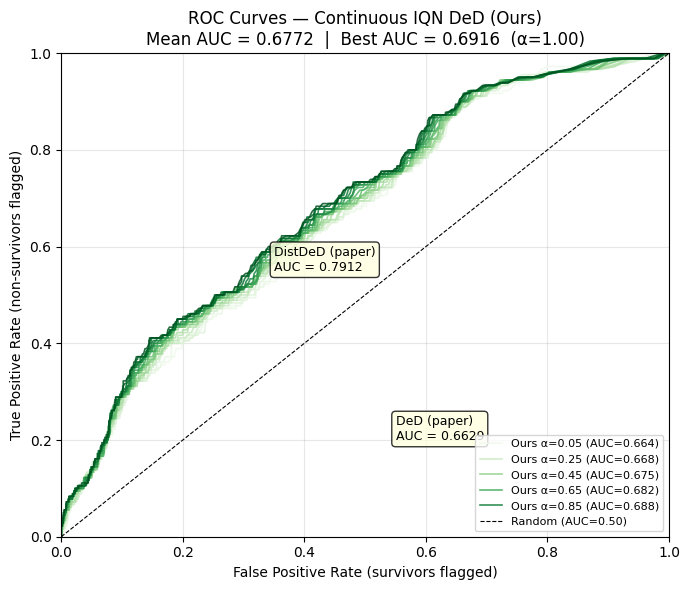

In [38]:
ns_colors = sns.color_palette('Greens', n_colors=20)

fig, ax = plt.subplots(figsize=(7, 6))

# Our continuous IQN curves (one per alpha)
for ii in range(20):
    label = (f'Ours α={VaR_thresholds[ii]:.2f} (AUC={auc_vals[ii]:.3f})'
             if ii % 4 == 0 else None)
    ax.plot(fpr[:, ii], tpr[:, ii], color=ns_colors[ii],
            linewidth=1.2, alpha=0.85, label=label)

# Paper baseline AUC reference — annotate as vertical lines on the AUC axis
# (we don't have the DeD FPR/TPR arrays, so we annotate the AUC values)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')

# Text annotations for paper baselines
for (name, auc_val), xpos, ypos in zip(
    [('DeD (paper)', 0.6629), ('DistDeD (paper)', 0.7912)],
    [0.55, 0.35],
    [0.20, 0.55],
):
    ax.annotate(
        f'{name}\nAUC = {auc_val:.4f}',
        xy=(xpos, ypos), fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8),
    )

ax.set_xlabel('False Positive Rate (survivors flagged)')
ax.set_ylabel('True Positive Rate (non-survivors flagged)')
ax.set_title(
    f'ROC Curves — Continuous IQN DeD (Ours)\n'
    f'Mean AUC = {auc_vals.mean():.4f}  |  Best AUC = {auc_vals.max():.4f}  '
    f'(α={VaR_thresholds[auc_vals.argmax()]:.2f})'
)
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
fig_roc = fig

## Figure 3 — AUC vs VaR threshold  *(paper Figure 8 equivalent)*

Horizontal lines = hard-coded paper baselines.  
Green curve = our continuous IQN results.

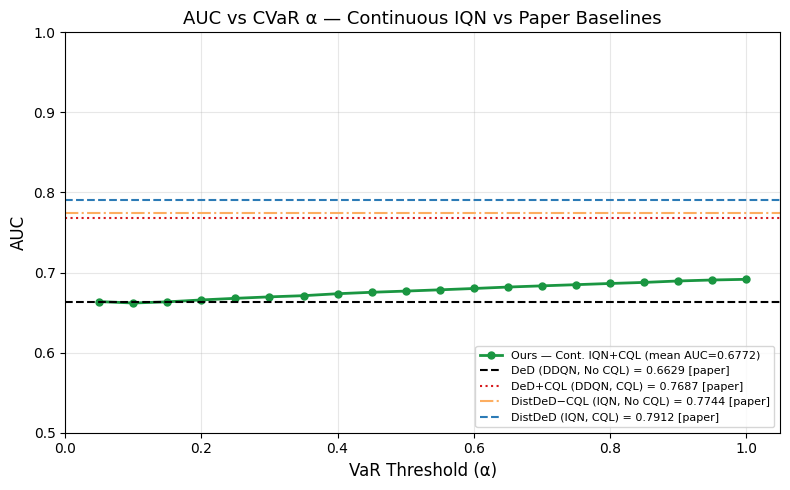

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))

# Our continuous IQN AUC curve
ax.plot(VaR_thresholds, auc_vals, 'o-', color='#1a9641', linewidth=2,
        markersize=5, label=f'Ours — Cont. IQN+CQL (mean AUC={auc_vals.mean():.4f})')

# Paper baselines as horizontal dashed lines
paper_styles = [
    ('DeD (DDQN, No CQL)',         0.6629, 'black',   '--'),
    ('DeD+CQL (DDQN, CQL)',        0.7687, '#d7191c', ':'),
    ('DistDeD−CQL (IQN, No CQL)', 0.7744, '#fdae61', '-.'),
    ('DistDeD (IQN, CQL)',         0.7912, '#2c7bb6', '--'),
]
for label, val, color, ls in paper_styles:
    ax.axhline(val, color=color, linestyle=ls, linewidth=1.5,
               label=f'{label} = {val:.4f} [paper]')

ax.set_xlabel('VaR Threshold (α)', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('AUC vs CVaR α — Continuous IQN vs Paper Baselines', fontsize=13)
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(0, 1.05)
ax.set_ylim(0.5, 1.0)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
fig_auc_var = fig

## Figure 4 — % Trajectories missed  *(paper Table 7 equivalent)*

A trajectory is *missed* if no flag is ever raised during it.  
Lower = better for non-survivors; higher = better for survivors (fewer false alarms).

We compute our numbers at the same δD / δR sweep used in `compare_flag_range`
(δD ∈ [−1, 0] swept over 1001 thresholds, δR = 1 + δD), then pick δD = −0.5 as the
fixed operating point matching the paper.

In [40]:
# Fixed operating point δD = -0.5  →  threshold index in linspace(0,1,1001) = 500
FIXED_THR_IDX = 500   # corresponds to thr=0.5, dn_thr=-0.5

# Compute % missed per alpha for our continuous model
our_missed_ns = np.zeros(20)  # non-survivors missed
our_missed_s  = np.zeros(20)  # survivors missed (false-alarm-free)

for traj in range(n_nonsurvivors):
    ns_dt = nonsurv_df[nonsurv_df.traj == traj]
    flags = np.stack(ns_dt.apply(compare_flag_range, axis=1).values)  # (T, 1001, 20)
    for ii in range(20):
        if not np.any(flags[:, FIXED_THR_IDX, ii]):
            our_missed_ns[ii] += 1
our_missed_ns = 100.0 * our_missed_ns / n_nonsurvivors

for traj in range(n_survivors):
    s_dt = surv_df[surv_df.traj == traj]
    flags = np.stack(s_dt.apply(compare_flag_range, axis=1).values)
    for ii in range(20):
        if not np.any(flags[:, FIXED_THR_IDX, ii]):
            our_missed_s[ii] += 1
our_missed_s = 100.0 * our_missed_s / n_survivors

print(f'Our model — non-survivors missed range : {our_missed_ns.min():.1f}% – {our_missed_ns.max():.1f}%')
print(f'Our model — survivors missed range     : {our_missed_s.min():.1f}% – {our_missed_s.max():.1f}%')
print(f'Paper DistDeD — NS missed range        : {PAPER_DISTDED_MISSED_NS.min():.1f}% – {PAPER_DISTDED_MISSED_NS.max():.1f}%')
print(f'Paper DeD     — NS missed              : {PAPER_DED_MISSED_NS:.1f}%')

Our model — non-survivors missed range : 53.3% – 94.4%
Our model — survivors missed range     : 74.4% – 99.5%
Paper DistDeD — NS missed range        : 4.8% – 41.9%
Paper DeD     — NS missed              : 59.3%


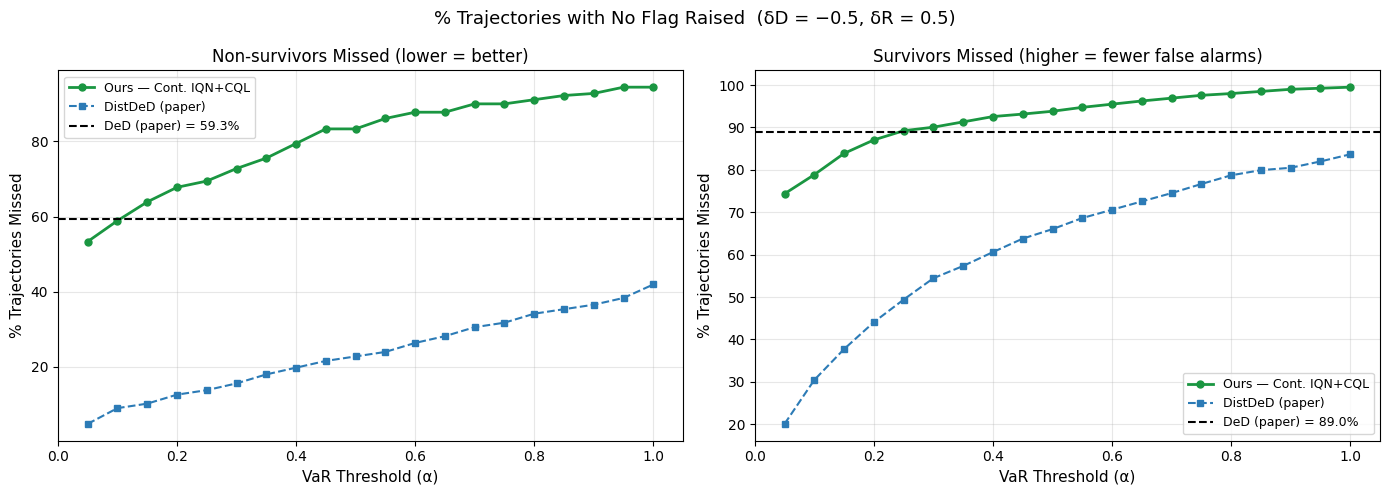

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# ── Non-survivors (lower = better) ───────────────────────────────────────────
ax = axes[0]
ax.plot(VaR_thresholds, our_missed_ns, 'o-', color='#1a9641', linewidth=2,
        markersize=5, label='Ours — Cont. IQN+CQL')
ax.plot(PAPER_VAR_ALPHAS, PAPER_DISTDED_MISSED_NS, 's--', color='#2c7bb6', linewidth=1.5,
        markersize=4, label='DistDeD (paper)')
ax.axhline(PAPER_DED_MISSED_NS, color='black', linestyle='--', linewidth=1.5,
           label=f'DeD (paper) = {PAPER_DED_MISSED_NS:.1f}%')
ax.set_xlabel('VaR Threshold (α)', fontsize=11)
ax.set_ylabel('% Trajectories Missed', fontsize=11)
ax.set_title('Non-survivors Missed (lower = better)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.05)

# ── Survivors (higher = better — fewer false alarms) ─────────────────────────
ax = axes[1]
ax.plot(VaR_thresholds, our_missed_s, 'o-', color='#1a9641', linewidth=2,
        markersize=5, label='Ours — Cont. IQN+CQL')
ax.plot(PAPER_VAR_ALPHAS, PAPER_DISTDED_MISSED_S, 's--', color='#2c7bb6', linewidth=1.5,
        markersize=4, label='DistDeD (paper)')
ax.axhline(PAPER_DED_MISSED_S, color='black', linestyle='--', linewidth=1.5,
           label=f'DeD (paper) = {PAPER_DED_MISSED_S:.1f}%')
ax.set_xlabel('VaR Threshold (α)', fontsize=11)
ax.set_ylabel('% Trajectories Missed', fontsize=11)
ax.set_title('Survivors Missed (higher = fewer false alarms)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.05)

fig.suptitle('% Trajectories with No Flag Raised  (δD = −0.5, δR = 0.5)', fontsize=13)
fig.tight_layout()
plt.show()
fig_missed = fig

## Figure 5 — Hours ahead of death  *(paper Figure 5 equivalent)*

For each non-surviving trajectory that raises a flag, how many hours before death was the first flag?  
Box plots over all 20 VaR α settings.

In [42]:
# Compute first-flag hours-before-death for each (trajectory, alpha) pair
# step column is negative (e.g. step=-3 means 3 hours before trajectory end)
# hours_before_death = abs(first_flag_step)

hours_ahead_per_alpha = [[] for _ in range(20)]  # list of lists

for traj in range(n_nonsurvivors):
    ns_dt = nonsurv_df[nonsurv_df.traj == traj]
    flags = np.stack(ns_dt.apply(compare_flag_range, axis=1).values)  # (T, 1001, 20)
    steps = ns_dt['step'].values  # negative integers
    for ii in range(20):
        col_flags = flags[:, FIXED_THR_IDX, ii]  # (T,)
        if np.any(col_flags):
            first_idx = np.where(col_flags)[0][0]
            hours_ahead_per_alpha[ii].append(abs(steps[first_idx]))

for ii in range(20):
    n = len(hours_ahead_per_alpha[ii])
    if n > 0:
        arr = np.array(hours_ahead_per_alpha[ii])
        print(f'α={VaR_thresholds[ii]:.2f}  n_flagged={n:3d}  '
              f'median={np.median(arr):.1f}h  mean={np.mean(arr):.1f}h  '
              f'range=[{arr.min()},{arr.max()}]')

α=0.05  n_flagged= 84  median=8.5h  mean=10.4h  range=[1,35]
α=0.10  n_flagged= 74  median=8.0h  mean=10.1h  range=[1,32]
α=0.15  n_flagged= 65  median=7.0h  mean=9.4h  range=[1,32]
α=0.20  n_flagged= 58  median=7.0h  mean=9.2h  range=[1,32]
α=0.25  n_flagged= 55  median=7.0h  mean=8.6h  range=[1,30]
α=0.30  n_flagged= 49  median=8.0h  mean=8.6h  range=[1,29]
α=0.35  n_flagged= 44  median=8.0h  mean=8.7h  range=[1,29]
α=0.40  n_flagged= 37  median=8.0h  mean=8.6h  range=[1,28]
α=0.45  n_flagged= 30  median=8.0h  mean=9.6h  range=[1,28]
α=0.50  n_flagged= 30  median=7.5h  mean=8.5h  range=[1,28]
α=0.55  n_flagged= 25  median=8.0h  mean=8.8h  range=[1,28]
α=0.60  n_flagged= 22  median=8.0h  mean=9.0h  range=[1,27]
α=0.65  n_flagged= 22  median=5.5h  mean=7.9h  range=[1,27]
α=0.70  n_flagged= 18  median=6.0h  mean=8.2h  range=[1,27]
α=0.75  n_flagged= 18  median=5.0h  mean=7.3h  range=[1,25]
α=0.80  n_flagged= 16  median=4.5h  mean=7.2h  range=[1,25]
α=0.85  n_flagged= 14  median=6.0h  me

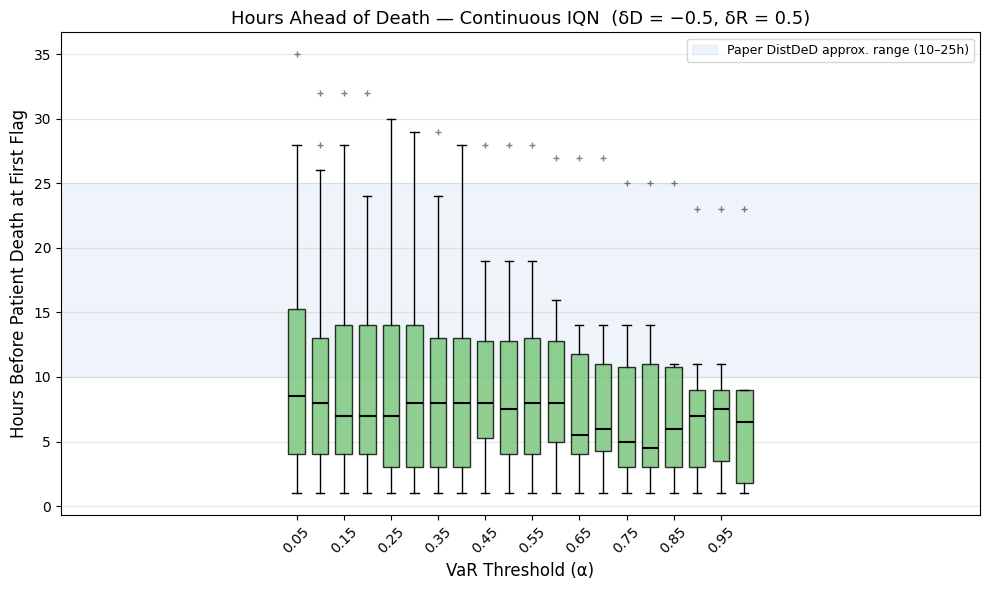

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

# Box plot data — one box per alpha
plot_data  = [np.array(hours_ahead_per_alpha[ii]) if hours_ahead_per_alpha[ii] else np.array([0])
              for ii in range(20)]
positions  = VaR_thresholds

bp = ax.boxplot(
    plot_data,
    positions=positions,
    widths=0.035,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    boxprops=dict(facecolor='#74c476', alpha=0.8),
    flierprops=dict(marker='+', markersize=4, alpha=0.5),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)

# Paper DistDeD reference (median hours ahead, from Table 7 / Figure 5)
# We annotate the approximate range visible in Figure 5 of the paper
ax.axhspan(10, 25, alpha=0.08, color='#2c7bb6',
           label='Paper DistDeD approx. range (10–25h)')

ax.set_xlabel('VaR Threshold (α)', fontsize=12)
ax.set_ylabel('Hours Before Patient Death at First Flag', fontsize=12)
ax.set_title('Hours Ahead of Death — Continuous IQN  (δD = −0.5, δR = 0.5)', fontsize=13)
ax.set_xticks(positions[::2])
ax.set_xticklabels([f'{a:.2f}' for a in positions[::2]], rotation=45)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
plt.show()
fig_hours = fig

## Figure 6 — Value traces around first flag  *(paper Figure 4 equivalent)*

Aggregated Q/V values in a ±window centred on each trajectory's first flag.

Computing aggregated value traces...
Non-survivor flag-aligned rows : 6080
Survivor flag-aligned rows     : 11780


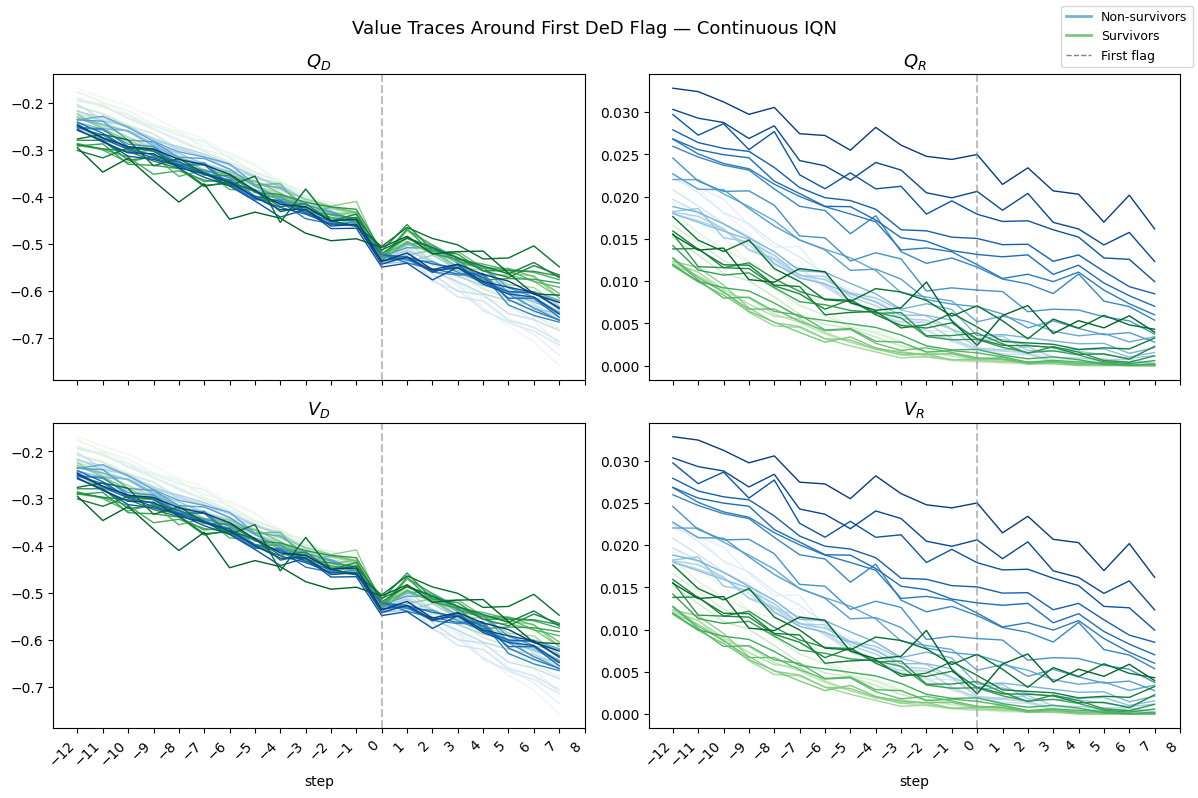

In [44]:
print('Computing aggregated value traces...')
ns_vals = comp_flag_agg_values(nonsurv_df, distributional=True)
s_vals  = comp_flag_agg_values(surv_df,    distributional=True)
print(f'Non-survivor flag-aligned rows : {len(ns_vals)}')
print(f'Survivor flag-aligned rows     : {len(s_vals)}')

if len(ns_vals) == 0 and len(s_vals) == 0:
    print('\nNo trajectories raised a flag — skip Figure 6.')
    fig_traces = None
else:
    ns_colors = sns.color_palette('Blues',  n_colors=20)
    s_colors  = sns.color_palette('Greens', n_colors=20)
    titles = [r'$Q_{D}$', r'$Q_{R}$', r'$V_{D}$', r'$V_{R}$']
    window_pre, window_post = 12, 8

    fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for idx, item in enumerate(['q_dn', 'q_rn', 'v_dn', 'v_rn']):
        ax = axs[idx // 2, idx % 2]
        for ivar in range(20):
            if len(ns_vals) > 0:
                ns_temp = ns_vals[ns_vals.var_index == ivar]
                if len(ns_temp) > 0:
                    sns.lineplot(x=ns_temp['step'], y=ns_temp[item],
                                 color=ns_colors[ivar], errorbar=None, linewidth=1, ax=ax)
            if len(s_vals) > 0:
                s_temp = s_vals[s_vals.var_index == ivar]
                if len(s_temp) > 0:
                    sns.lineplot(x=s_temp['step'], y=s_temp[item],
                                 color=s_colors[ivar], errorbar=None, linewidth=1, ax=ax)
        ax.axvline(x=0, ls='--', color='gray', alpha=0.5)
        ax.set_title(titles[idx], fontsize=13)
        ax.set_ylabel('')
        ax.set_xticks(np.arange(-window_pre, window_post + 1))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    fig.legend(
        handles=[
            Line2D([0], [0], color=ns_colors[9], linewidth=2, label='Non-survivors'),
            Line2D([0], [0], color=s_colors[9],  linewidth=2, label='Survivors'),
            Line2D([0], [0], color='gray', ls='--', linewidth=1, label='First flag'),
        ],
        loc='upper right', fontsize=9,
    )
    fig.suptitle('Value Traces Around First DeD Flag — Continuous IQN', fontsize=13)
    fig.tight_layout()
    plt.show()
    fig_traces = fig

## Table 1 — AUC comparison  *(paper Table 1 equivalent)*

Paper uses mean AUC over all VaR α settings for IQN models.

In [45]:
best_alpha_idx = int(auc_vals.argmax())
best_alpha     = float(VaR_thresholds[best_alpha_idx])
best_auc       = float(auc_vals[best_alpha_idx])
mean_auc       = float(auc_vals.mean())

rows = [
    # (Method, Architecture, Penalty, Source, Mean AUC, Best AUC)
    ('DeD',           'DDQN', 'No CQL', 'Paper',  0.6629,    0.6629),
    ('DeD+CQL',       'DDQN', 'CQL',    'Paper',  0.7687,    0.7687),
    ('DistDeD−CQL',   'IQN',  'No CQL', 'Paper',  0.7744,    0.7744),
    ('DistDeD',       'IQN',  'CQL',    'Paper',  0.7912,    0.7912),
    ('Ours (Cont.)',  'IQN',  'CQL',    'Ours',   mean_auc,  best_auc),
]

df_table = pd.DataFrame(
    rows,
    columns=['Method', 'Architecture', 'Penalty', 'Source', 'Mean AUC', 'Best AUC'],
)
df_table['Mean AUC'] = df_table['Mean AUC'].map('{:.4f}'.format)
df_table['Best AUC'] = df_table['Best AUC'].map('{:.4f}'.format)
print(df_table.to_string(index=False))

print(f'\nOur best α = {best_alpha:.2f}  |  Best AUC = {best_auc:.4f}  |  Mean AUC = {mean_auc:.4f}')

# Non-survivors and survivors flagged at best alpha
first_flags_ns, first_flags_s = [], []
from analysis_utils import compare_flag_range
for traj in range(n_nonsurvivors):
    dt = nonsurv_df[nonsurv_df.traj == traj]
    flags_all = np.stack(dt.apply(compare_flag_range, axis=1).values)
    any_flag  = np.any(flags_all[:, :, best_alpha_idx], axis=1)
    if any_flag.any():
        first_flags_ns.append(int(np.where(any_flag)[0][0]) + int(dt['step'].iloc[0]))
for traj in range(n_survivors):
    dt = surv_df[surv_df.traj == traj]
    flags_all = np.stack(dt.apply(compare_flag_range, axis=1).values)
    any_flag  = np.any(flags_all[:, :, best_alpha_idx], axis=1)
    if any_flag.any():
        first_flags_s.append(int(np.where(any_flag)[0][0]) + int(dt['step'].iloc[0]))

pct_ns = 100 * len(first_flags_ns) / max(n_nonsurvivors, 1)
pct_s  = 100 * len(first_flags_s)  / max(n_survivors,    1)

print('\n' + '=' * 60)
print(' Continuous IQN Dead-End Detection — Summary')
print('=' * 60)
print(f' Total test trajectories   : {n_survivors + n_nonsurvivors}')
print(f'   Survivors               : {n_survivors}')
print(f'   Non-survivors           : {n_nonsurvivors}')
print(f' Best CVaR alpha           : {best_alpha:.2f}  (index {best_alpha_idx})')
print(f' Best AUC                  : {best_auc:.4f}')
print(f' Mean AUC across alphas    : {mean_auc:.4f}')
print(f' Non-survivors flagged     : {len(first_flags_ns)}/{n_nonsurvivors} ({pct_ns:.1f}%)')
print(f' Survivors flagged (FP)    : {len(first_flags_s)}/{n_survivors} ({pct_s:.1f}%)')
if first_flags_ns:
    print(f' Mean first-flag (NS)      : {np.mean([abs(x) for x in first_flags_ns]):.1f}h from end')
print('=' * 60)
print()
print(' Paper DistDeD  — Best AUC : 0.7912  (mean over alpha)')
print(f' Paper DeD      — AUC      : 0.6629')
print(f' Our model      — Mean AUC : {mean_auc:.4f}  Best AUC : {best_auc:.4f}')
print('=' * 60)

      Method Architecture Penalty Source Mean AUC Best AUC
         DeD         DDQN  No CQL  Paper   0.6629   0.6629
     DeD+CQL         DDQN     CQL  Paper   0.7687   0.7687
 DistDeD−CQL          IQN  No CQL  Paper   0.7744   0.7744
     DistDeD          IQN     CQL  Paper   0.7912   0.7912
Ours (Cont.)          IQN     CQL   Ours   0.6772   0.6916

Our best α = 1.00  |  Best AUC = 0.6916  |  Mean AUC = 0.6772

 Continuous IQN Dead-End Detection — Summary
 Total test trajectories   : 1377
   Survivors               : 1197
   Non-survivors           : 180
 Best CVaR alpha           : 1.00  (index 19)
 Best AUC                  : 0.6916
 Mean AUC across alphas    : 0.6772
 Non-survivors flagged     : 180/180 (100.0%)
 Survivors flagged (FP)    : 1197/1197 (100.0%)
 Mean first-flag (NS)      : 47.3h from end

 Paper DistDeD  — Best AUC : 0.7912  (mean over alpha)
 Paper DeD      — AUC      : 0.6629
 Our model      — Mean AUC : 0.6772  Best AUC : 0.6916


## Save all figures

In [46]:
os.makedirs(CKPT_DIR, exist_ok=True)

fig_training.savefig(os.path.join(CKPT_DIR, 'comp_fig1_training_curves.png'),
                     dpi=150, bbox_inches='tight')
print('Saved: comp_fig1_training_curves.png')

fig_roc.savefig(os.path.join(CKPT_DIR, 'comp_fig2_roc_curves.png'),
                dpi=150, bbox_inches='tight')
print('Saved: comp_fig2_roc_curves.png')

fig_auc_var.savefig(os.path.join(CKPT_DIR, 'comp_fig3_auc_vs_var.png'),
                    dpi=150, bbox_inches='tight')
print('Saved: comp_fig3_auc_vs_var.png')

fig_missed.savefig(os.path.join(CKPT_DIR, 'comp_fig4_missed_trajs.png'),
                   dpi=150, bbox_inches='tight')
print('Saved: comp_fig4_missed_trajs.png')

fig_hours.savefig(os.path.join(CKPT_DIR, 'comp_fig5_hours_ahead.png'),
                  dpi=150, bbox_inches='tight')
print('Saved: comp_fig5_hours_ahead.png')

if fig_traces is not None:
    fig_traces.savefig(os.path.join(CKPT_DIR, 'comp_fig6_value_traces.png'),
                       dpi=150, bbox_inches='tight')
    print('Saved: comp_fig6_value_traces.png')
else:
    print('comp_fig6_value_traces.png skipped (no flags raised)')

# Save AUC table to CSV
auc_df = pd.DataFrame({'alpha': VaR_thresholds, 'our_auc': auc_vals})
auc_df.to_csv(os.path.join(CKPT_DIR, 'comp_auc_table.csv'), index=False)
print('Saved: comp_auc_table.csv')

print(f'\nAll outputs saved to: {CKPT_DIR}')

Saved: comp_fig1_training_curves.png
Saved: comp_fig2_roc_curves.png
Saved: comp_fig3_auc_vs_var.png
Saved: comp_fig4_missed_trajs.png
Saved: comp_fig5_hours_ahead.png
Saved: comp_fig6_value_traces.png
Saved: comp_auc_table.csv

All outputs saved to: /content/drive/MyDrive/ContinuousDeD-mimic/runs/iqn_continuous_mimic/
